# FashionMNIST Image Classifier (PyTorch)

This notebook:

1. Loads the **FashionMNIST** dataset from `torchvision`.
2. Splits it into **train / validation / test** sets.
3. Trains a simple **baseline MLP**, then an **improved CNN** (batch norm, dropout, data augmentation, AdamW + OneCycle learning-rate schedule) to raise accuracy.
4. Plots **train vs. validation accuracy (and loss) across epochs**.
5. Evaluates the best model (selected on validation accuracy) on the held-out **test** set.

## 1. Setup

In [1]:
import time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.14.0+cu130 | device: cpu


## 2. Data: load and split into train / validation / test

FashionMNIST ships with 60,000 training images and 10,000 test images (28×28 grayscale, 10 classes).

- **Test (10,000)**: the official test split, used **only once** at the end.
- **Train (50,000) / Validation (10,000)**: a seeded random split of the official training set.

Normalization statistics are computed on the training subset only. The training subset gets light augmentation (random horizontal flip + random crop with padding); validation and test do not.

In [2]:
DATA_DIR = "data"
CLASSES = datasets.FashionMNIST.classes

# Split indices of the official training set (seeded, reproducible)
full_train_raw = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
n_total, n_val = len(full_train_raw), 10_000
perm = torch.randperm(n_total, generator=torch.Generator().manual_seed(SEED))
train_idx, val_idx = perm[n_val:].tolist(), perm[:n_val].tolist()

# Mean / std from the training subset only (avoid leaking validation info)
train_pixels = full_train_raw.data[train_idx].float() / 255.0
MEAN, STD = train_pixels.mean().item(), train_pixels.std().item()
print(f"mean={MEAN:.4f}  std={STD:.4f}")

eval_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((MEAN,), (STD,))])
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

# Two views of the same underlying data so train/val can use different transforms
train_ds = Subset(datasets.FashionMNIST(DATA_DIR, train=True, transform=train_tf), train_idx)
val_ds   = Subset(datasets.FashionMNIST(DATA_DIR, train=True, transform=eval_tf),  val_idx)
test_ds  = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2)

mean=0.2859  std=0.3529


train=50000  val=10000  test=10000


Class balance per split and a few sample images:

T-shirt/top  train= 5020  val=  980  test= 1000
Trouser      train= 5021  val=  979  test= 1000
Pullover     train= 4939  val= 1061  test= 1000
Dress        train= 5026  val=  974  test= 1000
Coat         train= 4954  val= 1046  test= 1000
Sandal       train= 4945  val= 1055  test= 1000
Shirt        train= 5016  val=  984  test= 1000
Sneaker      train= 5007  val=  993  test= 1000
Bag          train= 5043  val=  957  test= 1000
Ankle boot   train= 5029  val=  971  test= 1000


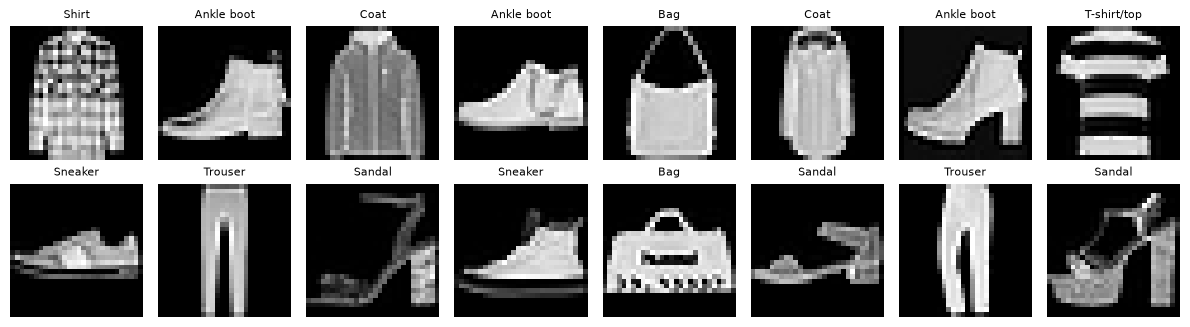

In [3]:
tr_counts = np.bincount(full_train_raw.targets[train_idx].numpy(), minlength=10)
va_counts = np.bincount(full_train_raw.targets[val_idx].numpy(), minlength=10)
te_counts = np.bincount(test_ds.targets.numpy(), minlength=10)
for c, a, b, t in zip(CLASSES, tr_counts, va_counts, te_counts):
    print(f"{c:<12} train={a:5d}  val={b:5d}  test={t:5d}")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, i in zip(axes.flat, range(16)):
    img, lbl = full_train_raw[train_idx[i]]
    ax.imshow(img, cmap="gray"); ax.set_title(CLASSES[lbl], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Training utilities

In [4]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None):
    """One pass over `loader`. Trains if an optimizer is given, otherwise evaluates."""
    train = optimizer is not None
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            total_loss += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n


def fit(model, epochs, optimizer, scheduler=None, criterion=None, eval_criterion=None):
    """Train for `epochs`, track history and keep the weights with the best validation accuracy."""
    criterion = criterion or nn.CrossEntropyLoss()
    eval_criterion = eval_criterion or nn.CrossEntropyLoss()
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best_acc, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, criterion, optimizer, scheduler)
        vl, va = run_epoch(model, val_loader, eval_criterion)
        for k, v in zip(hist, [tl, ta, vl, va]):
            hist[k].append(v)
        if va > best_acc:
            best_acc, best_state = va, copy.deepcopy(model.state_dict())
        print(f"epoch {ep:2d}/{epochs} | train loss {tl:.4f} acc {ta:.4f} | "
              f"val loss {vl:.4f} acc {va:.4f} | {time.time()-t0:.0f}s")
    model.load_state_dict(best_state)
    print(f"best val acc: {best_acc:.4f}")
    return hist


def plot_history(hist, title):
    ep = range(1, len(hist["train_acc"]) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(ep, hist["train_acc"], "o-", label="train")
    a1.plot(ep, hist["val_acc"], "s-", label="validation")
    a1.set(title=f"{title}: accuracy", xlabel="epoch", ylabel="accuracy"); a1.grid(alpha=.3); a1.legend()
    a2.plot(ep, hist["train_loss"], "o-", label="train")
    a2.plot(ep, hist["val_loss"], "s-", label="validation")
    a2.set(title=f"{title}: loss", xlabel="epoch", ylabel="cross-entropy"); a2.grid(alpha=.3); a2.legend()
    plt.tight_layout(); plt.show()


count_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)

## 4. Baseline: multilayer perceptron

A plain fully-connected network gives a reference point for how much the CNN improves things.

baseline params: 235,146


epoch  1/10 | train loss 0.7148 acc 0.7326 | val loss 0.5557 acc 0.7830 | 13s


epoch  2/10 | train loss 0.5393 acc 0.7994 | val loss 0.4648 acc 0.8226 | 14s


epoch  3/10 | train loss 0.4856 acc 0.8181 | val loss 0.4293 acc 0.8443 | 13s


epoch  4/10 | train loss 0.4600 acc 0.8286 | val loss 0.4118 acc 0.8478 | 13s


...

epoch  6/10 | train loss 0.4269 acc 0.8419 | val loss 0.3997 acc 0.8499 | 14s


epoch  7/10 | train loss 0.4139 acc 0.8472 | val loss 0.3710 acc 0.8650 | 14s


epoch  8/10 | train loss 0.4019 acc 0.8504 | val loss 0.3732 acc 0.8656 | 14s


epoch  9/10 | train loss 0.3996 acc 0.8525 | val loss 0.3751 acc 0.8625 | 13s


epoch 10/10 | train loss 0.3874 acc 0.8569 | val loss 0.3733 acc 0.8635 | 14s
best val acc: 0.8656


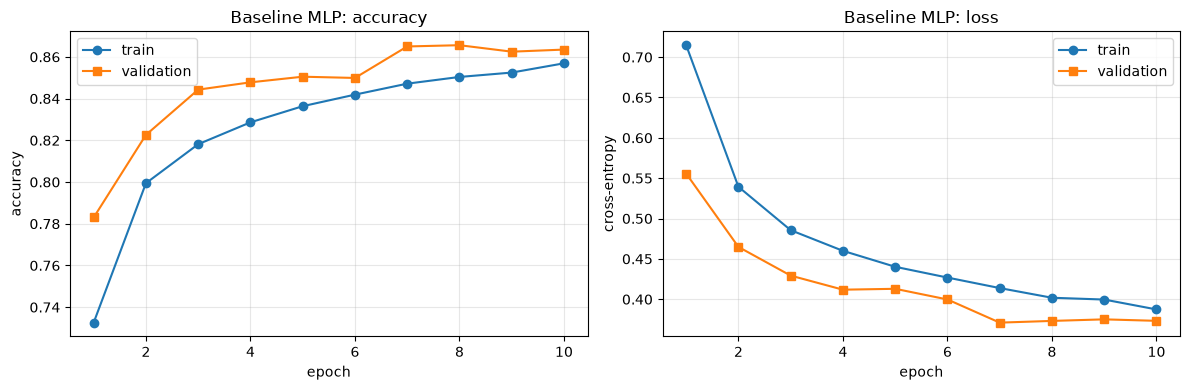

In [5]:
torch.manual_seed(SEED)
baseline = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
print(f"baseline params: {count_params(baseline):,}")

BASE_EPOCHS = 10
base_hist = fit(baseline, BASE_EPOCHS, torch.optim.Adam(baseline.parameters(), lr=1e-3))
plot_history(base_hist, "Baseline MLP")

## 5. Improved model: convolutional neural network

Changes aimed at improving accuracy:

- **Convolutional blocks** (3×3 conv → BatchNorm → ReLU, ×2, then max-pool) exploit spatial structure: 32 → 64 → 128 channels.
- **Batch normalization** for faster, more stable training.
- **Dropout** (after each block and in the classifier) and **data augmentation** to reduce overfitting.
- **AdamW** with weight decay, a **OneCycle** learning-rate schedule and **label smoothing**.
- **Model selection on validation accuracy** (best epoch's weights are kept).

In [6]:
def conv_block(c_in, c_out, p_drop=0.25):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(p_drop),
    )

class FashionCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),     # 28 -> 14
            conv_block(32, 64),    # 14 -> 7
            conv_block(64, 128),   # 7  -> 3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(SEED)
cnn = FashionCNN().to(device)
print(f"CNN params: {count_params(cnn):,}")

CNN params: 585,130


In [7]:
EPOCHS = 15
optimizer = torch.optim.AdamW(cnn.parameters(), lr=3e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-3, epochs=EPOCHS, steps_per_epoch=len(train_loader))

cnn_hist = fit(cnn, EPOCHS, optimizer, scheduler,
               criterion=nn.CrossEntropyLoss(label_smoothing=0.1))

epoch  1/15 | train loss 1.2796 acc 0.6558 | val loss 0.5443 acc 0.8073 | 87s


epoch  2/15 | train loss 0.9260 acc 0.8176 | val loss 0.4168 acc 0.8549 | 86s


epoch  3/15 | train loss 0.8550 acc 0.8535 | val loss 0.3770 acc 0.8793 | 87s


epoch  4/15 | train loss 0.8202 acc 0.8694 | val loss 0.3308 acc 0.8959 | 86s


epoch  5/15 | train loss 0.7924 acc 0.8810 | val loss 0.3189 acc 0.9019 | 86s


...

epoch 11/15 | train loss 0.7014 acc 0.9220 | val loss 0.2582 acc 0.9318 | 86s


epoch 12/15 | train loss 0.6920 acc 0.9241 | val loss 0.2508 acc 0.9338 | 87s


epoch 13/15 | train loss 0.6818 acc 0.9295 | val loss 0.2446 acc 0.9383 | 85s


epoch 14/15 | train loss 0.6763 acc 0.9309 | val loss 0.2412 acc 0.9382 | 86s


epoch 15/15 | train loss 0.6729 acc 0.9335 | val loss 0.2391 acc 0.9393 | 86s
best val acc: 0.9393


## 6. Accuracy along the epochs (train vs. validation)

Note: training accuracy is measured on augmented images with dropout active, so it can sit slightly *below* validation accuracy early on — that is expected with this kind of regularization.

Also, the CNN's *training* loss includes label smoothing (0.1) while validation loss is plain cross-entropy, so the train loss curve sits higher by construction — compare accuracy curves for a like-for-like view.

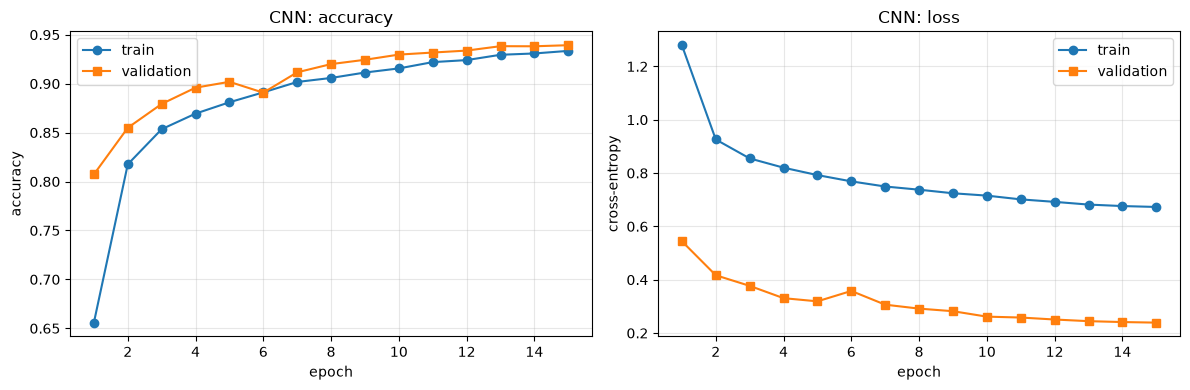

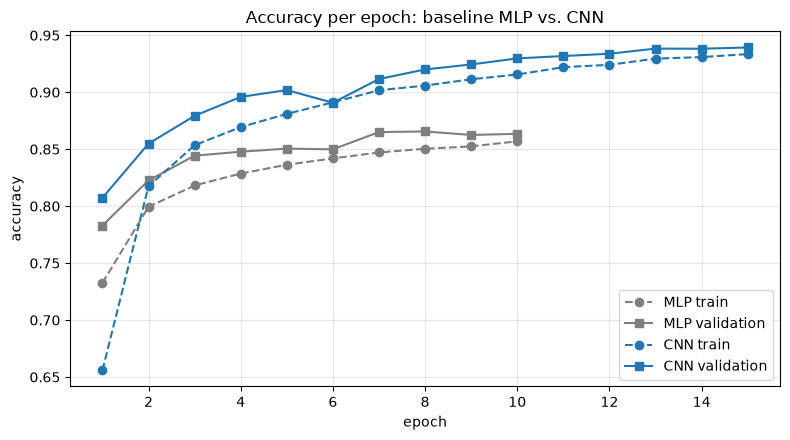

In [8]:
plot_history(cnn_hist, "CNN")

# Side-by-side comparison of both models' accuracy curves
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(base_hist["train_acc"]) + 1), base_hist["train_acc"], "o--", c="tab:gray", label="MLP train")
plt.plot(range(1, len(base_hist["val_acc"]) + 1),   base_hist["val_acc"],   "s-",  c="tab:gray", label="MLP validation")
plt.plot(range(1, len(cnn_hist["train_acc"]) + 1),  cnn_hist["train_acc"],  "o--", c="tab:blue", label="CNN train")
plt.plot(range(1, len(cnn_hist["val_acc"]) + 1),    cnn_hist["val_acc"],    "s-",  c="tab:blue", label="CNN validation")
plt.title("Accuracy per epoch: baseline MLP vs. CNN"); plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

## 7. Evaluation on the test set

The test set was not used for training or model selection. Both models are evaluated for comparison.

In [9]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu())
        labels.append(y)
    return torch.cat(preds), torch.cat(labels)


def confusion_matrix(y_true, y_pred, n_classes=10):
    """Rows = true class, columns = predicted class."""
    return torch.bincount(y_true * n_classes + y_pred, minlength=n_classes ** 2).reshape(n_classes, n_classes)


def classification_report(y_true, y_pred, target_names, digits=4):
    """Per-class precision / recall / F1 plus accuracy, macro and weighted averages."""
    cm = confusion_matrix(y_true, y_pred, len(target_names)).double()
    tp = cm.diag()
    support = cm.sum(1)                                    # true samples per class
    precision = tp / cm.sum(0).clamp(min=1)                # divided by predicted per class
    recall = tp / support.clamp(min=1)
    f1 = 2 * precision * recall / (precision + recall).clamp(min=1e-12)
    w = support / support.sum()

    width = max(len(n) for n in target_names + ["weighted avg"])
    fmt = f"{{:>{width}}} {{:>9.{digits}f}} {{:>9.{digits}f}} {{:>9.{digits}f}} {{:>9d}}"
    lines = [f"{'':>{width}} {'precision':>9} {'recall':>9} {'f1-score':>9} {'support':>9}", ""]
    for i, name in enumerate(target_names):
        lines.append(fmt.format(name, precision[i], recall[i], f1[i], int(support[i])))
    n = int(support.sum())
    acc = (tp.sum() / n).item()
    lines += ["", f"{'accuracy':>{width}} {'':>9} {'':>9} {acc:>9.{digits}f} {n:>9d}",
              fmt.format("macro avg", precision.mean(), recall.mean(), f1.mean(), n),
              fmt.format("weighted avg", (precision * w).sum(), (recall * w).sum(), (f1 * w).sum(), n)]
    return "\n".join(lines)


base_pred, y_test = predict(baseline, test_loader)
cnn_pred, _ = predict(cnn, test_loader)
base_test_acc = (base_pred == y_test).float().mean().item()
cnn_test_acc = (cnn_pred == y_test).float().mean().item()

print(f"Baseline MLP test accuracy: {base_test_acc:.4f}")
print(f"CNN          test accuracy: {cnn_test_acc:.4f}")
print(f"Test error reduced by {(1 - (1 - cnn_test_acc) / (1 - base_test_acc)) * 100:.1f}% relative to the baseline\n")
print(classification_report(y_test, cnn_pred, target_names=CLASSES, digits=4))

Baseline MLP test accuracy: 0.8588
CNN          test accuracy: 0.9330
Test error reduced by 52.5% relative to the baseline

              precision    recall  f1-score   support

 T-shirt/top     0.8946    0.8830    0.8888      1000
     Trouser     0.9940    0.9910    0.9925      1000
    Pullover     0.9216    0.8940    0.9076      1000
       Dress     0.9341    0.9360    0.9351      1000
        Coat     0.8729    0.9270    0.8991      1000
      Sandal     0.9869    0.9760    0.9814      1000
       Shirt     0.8035    0.7890    0.7962      1000
     Sneaker     0.9525    0.9820    0.9670      1000
         Bag     0.9940    0.9900    0.9920      1000
  Ankle boot     0.9776    0.9620    0.9698      1000

    accuracy                         0.9330     10000
   macro avg     0.9332    0.9330    0.9329     10000
weighted avg     0.9332    0.9330    0.9329     10000



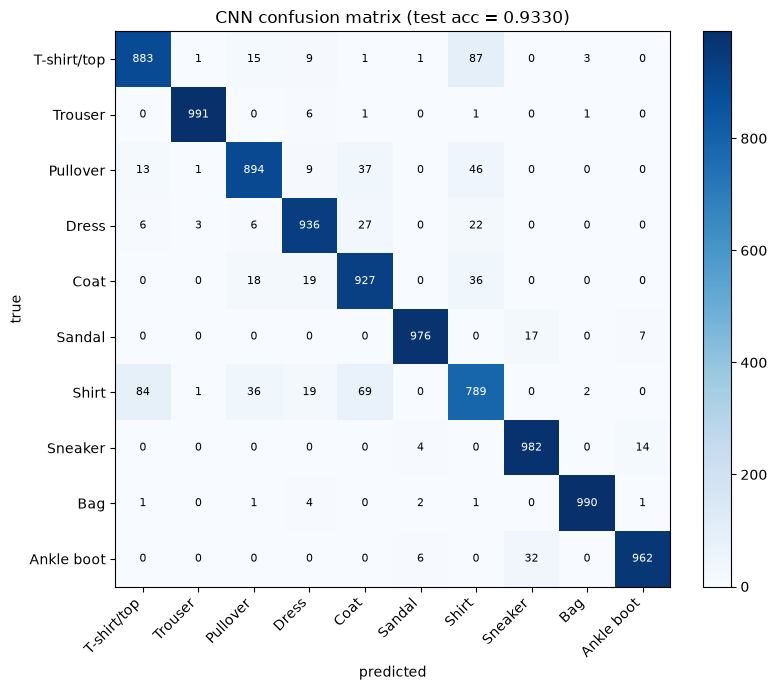

In [10]:
cm = confusion_matrix(y_test, cnn_pred)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j].item(), ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xlabel="predicted", ylabel="true", title=f"CNN confusion matrix (test acc = {cnn_test_acc:.4f})")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

Some test predictions (red = misclassified):

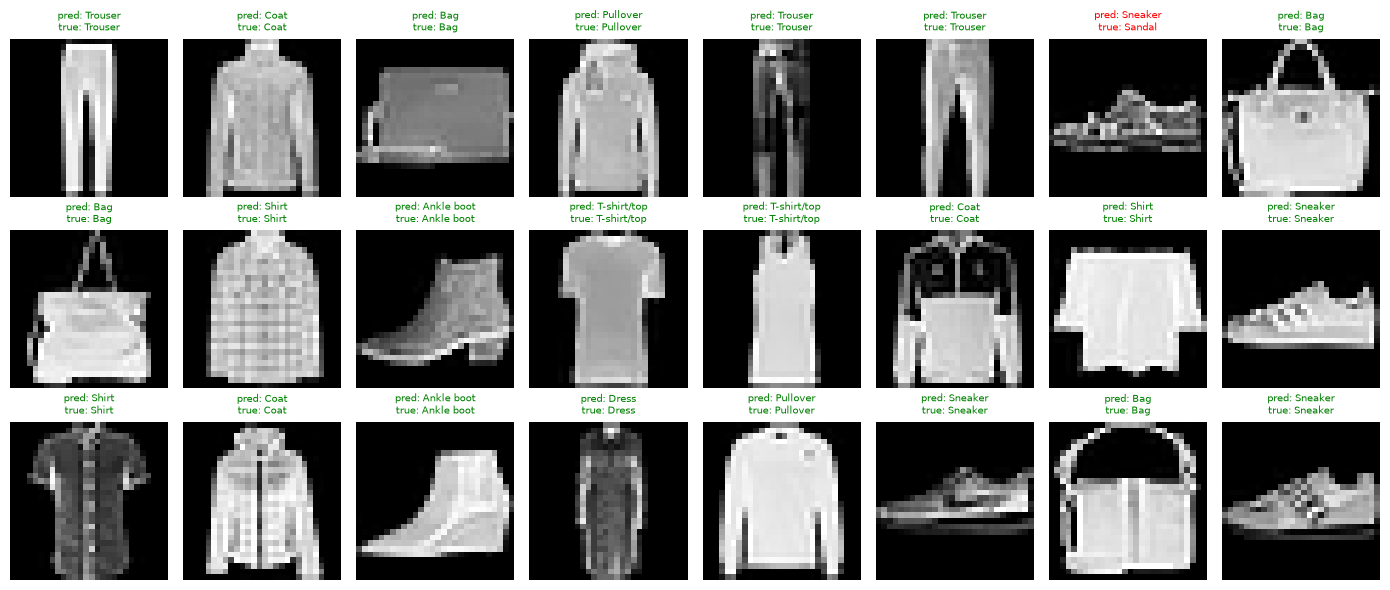

In [11]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(test_ds), 24, replace=False)
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, i in zip(axes.flat, idx):
    ax.imshow(test_ds.data[i], cmap="gray"); ax.axis("off")
    p, t = cnn_pred[i].item(), y_test[i].item()
    ok = p == t
    ax.set_title(f"pred: {CLASSES[p]}\ntrue: {CLASSES[t]}", fontsize=7,
                 color="green" if ok else "red")
plt.tight_layout(); plt.show()

## 8. Save the trained model

In [12]:
torch.save({"state_dict": cnn.state_dict(), "mean": MEAN, "std": STD, "classes": CLASSES},
           "fashion_cnn.pt")
print("saved to fashion_cnn.pt")

saved to fashion_cnn.pt


## Summary

| Model | Params | Best val acc | Test acc |
|---|---|---|---|
| Baseline MLP (10 epochs) | 235K | 0.8656 | 0.8588 |
| CNN (15 epochs) | 585K | 0.9393 | **0.9330** |

- Data: 50,000 train / 10,000 validation (seeded split of the official training set) / 10,000 test (official test set).
- The CNN (BatchNorm, dropout, augmentation, AdamW + OneCycle, label smoothing) cuts test error by ~52% relative to the baseline.
- Train vs. validation accuracy per epoch is plotted in section 6: validation accuracy climbs steadily with no sign of overfitting, so more epochs would likely help a bit further.
- Hardest class is **Shirt** (F1 ≈ 0.80), mostly confused with T-shirt/top, Pullover and Coat (see confusion matrix).

*(Numbers are from a CPU run with `SEED = 42`; small differences may occur on other hardware.)*